<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/S%26P500_Constituent_Analysis/S%26P_Constituent_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (20,10)

In [16]:
df = pd.read_excel("/content/holdings-daily-us-en-spy.xlsx", skiprows = [0,1,2,3], nrows = 10)
df.head(10)

,Name,Ticker,Identifier,SEDOL,Weight,Sector,Shares Held,Local Currency
0,NVIDIA CORP,NVDA,67066G104,2379504,7.671834,-,291909898,USD
1,APPLE INC,AAPL,037833100,2046251,6.536703,-,177504504,USD
2,MICROSOFT CORP,MSFT,594918104,2588173,5.996708,-,89283285,USD
3,AMAZON.COM INC,AMZN,023135106,2000019,3.951964,-,116861206,USD
4,ALPHABET INC CL A,GOOGL,02079K305,BYVY8G0,3.083929,-,69896115,USD
5,BROADCOM INC,AVGO,11135F101,BDZ78H9,2.737300,-,56728686,USD
6,ALPHABET INC CL C,GOOG,02079K107,BYY88Y7,2.466259,-,55859519,USD
7,META PLATFORMS INC CLASS A,META,30303M102,B7TL820,2.425940,-,26162347,USD
8,TESLA INC,TSLA,88160R101,B616C79,2.051349,-,33755149,USD
9,BERKSHIRE HATHAWAY INC CL B,BRK.B,084670702,2073390,1.543036,-,22028259,USD


In [43]:
tickers = [s.replace(".", "-") for s in df.Ticker.values]
tickers.append("^GSPC")
print(tickers)

data = yf.download(tickers, start = "2023-01-01", end="2026-01-01")["Close"]
data.head()

/tmp/ipython-input-2877872370.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = "2023-01-01", end="2026-01-01")["Close"]
[**********************45%                       ]  5 of 11 completed

['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B', '^GSPC']


[*********************100%***********************]  11 of 11 completed


Ticker,AAPL,AMZN,AVGO,BRK-B,GOOG,GOOGL,META,MSFT,NVDA,TSLA,^GSPC
Date,,,,,,,,,,,
2023-01-03,123.211220,85.820000,52.918915,309.910004,89.032242,88.451691,123.874695,233.985641,14.300685,108.099998,3824.139893
2023-01-04,124.482033,85.139999,53.565258,314.549988,88.049614,87.419479,126.486458,223.750351,14.734248,113.639999,3852.969971
2023-01-05,123.161942,83.120003,53.066170,312.899994,86.124054,85.553574,126.059433,217.118896,14.250735,110.339996,3808.100098
2023-01-06,127.693581,86.080002,56.260536,318.690002,87.503716,86.685028,129.118073,219.677719,14.844142,113.059998,3895.080078
2023-01-09,128.215698,87.360001,55.157181,315.529999,88.138947,87.359924,128.571884,221.816574,15.612370,119.769997,3892.090088


In [46]:
data.head()

Ticker,AAPL,AMZN,AVGO,BRK-B,GOOG,GOOGL,META,MSFT,NVDA,TSLA,^GSPC
Date,,,,,,,,,,,
2023-01-03,123.211220,85.820000,52.918915,309.910004,89.032242,88.451691,123.874695,233.985641,14.300685,108.099998,3824.139893
2023-01-04,124.482033,85.139999,53.565258,314.549988,88.049614,87.419479,126.486458,223.750351,14.734248,113.639999,3852.969971
2023-01-05,123.161942,83.120003,53.066170,312.899994,86.124054,85.553574,126.059433,217.118896,14.250735,110.339996,3808.100098
2023-01-06,127.693581,86.080002,56.260536,318.690002,87.503716,86.685028,129.118073,219.677719,14.844142,113.059998,3895.080078
2023-01-09,128.215698,87.360001,55.157181,315.529999,88.138947,87.359924,128.571884,221.816574,15.612370,119.769997,3892.090088


In [49]:
data.index

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-17',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=752, freq=None)

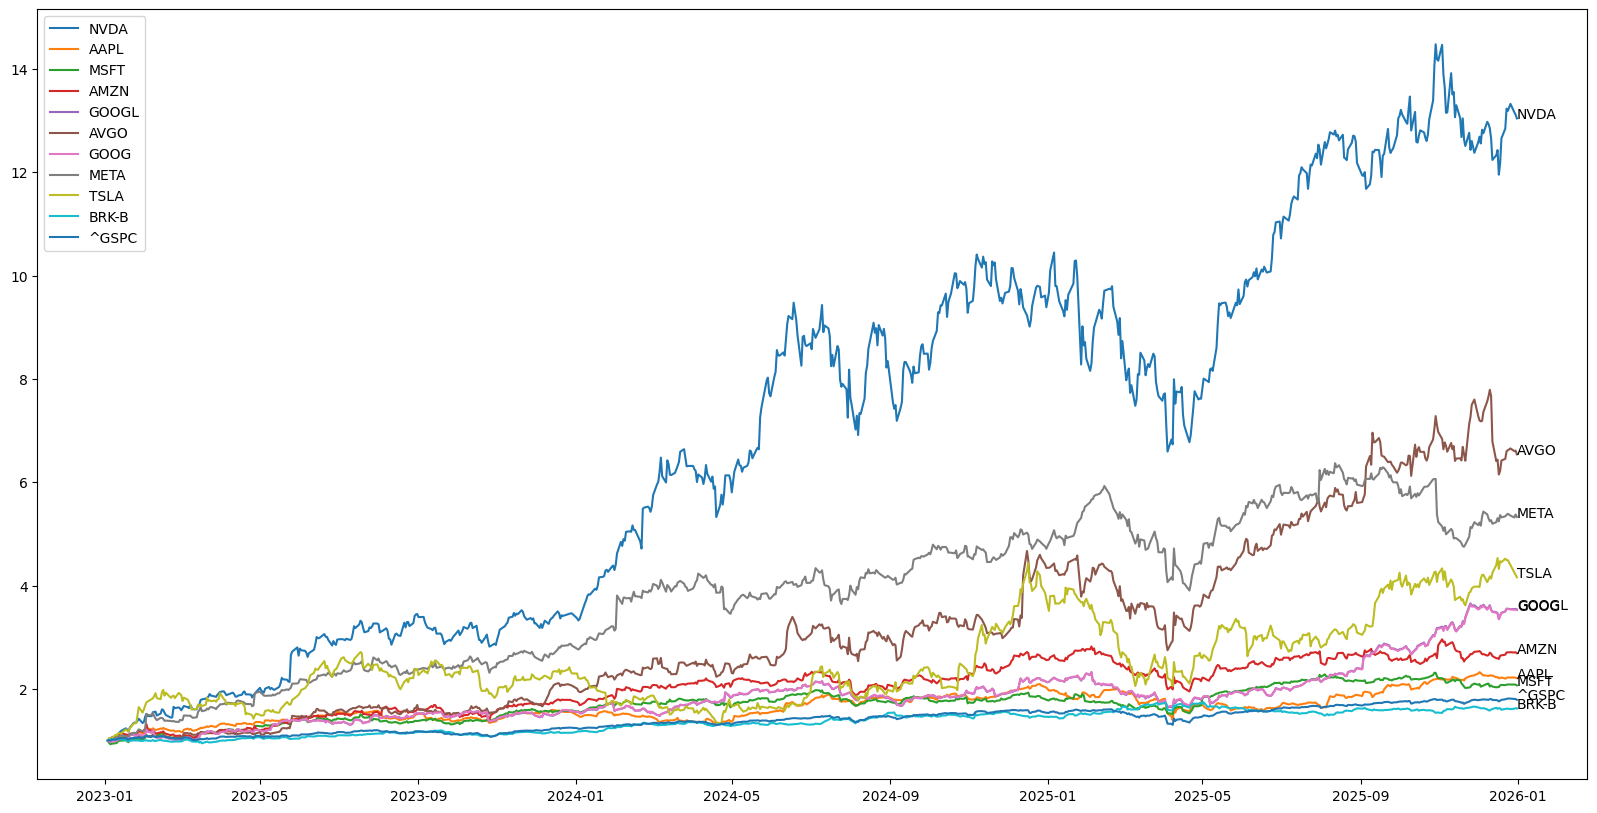

In [68]:
fig, ax = plt.subplots()

for ticker in tickers:
  ax.plot(data.index, data[ticker].values/data[ticker].values[0], label = ticker)
  ax.text(data.index[-1], (data[ticker].values/data[ticker].values[0])[-1], ticker)

plt.legend(tickers)
plt.show()

In [69]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,AMZN,AVGO,BRK-B,GOOG,GOOGL,META,MSFT,NVDA,TSLA,^GSPC
Date,,,,,,,,,,,
2023-01-04,0.010314,-0.007924,0.012214,0.014972,-0.011037,-0.011670,0.021084,-0.043743,0.030318,0.051249,0.007539
2023-01-05,-0.010605,-0.023726,-0.009317,-0.005246,-0.021869,-0.021344,-0.003376,-0.029638,-0.032816,-0.029039,-0.011646
2023-01-06,0.036794,0.035611,0.060196,0.018504,0.016019,0.013225,0.024263,0.011785,0.041640,0.024651,0.022841
2023-01-09,0.004089,0.014870,-0.019612,-0.009916,0.007259,0.007786,-0.004230,0.009736,0.051753,0.059349,-0.000768
2023-01-10,0.004457,0.028732,-0.003397,0.002599,0.004955,0.004545,0.027188,0.007617,0.017981,-0.007681,0.006978


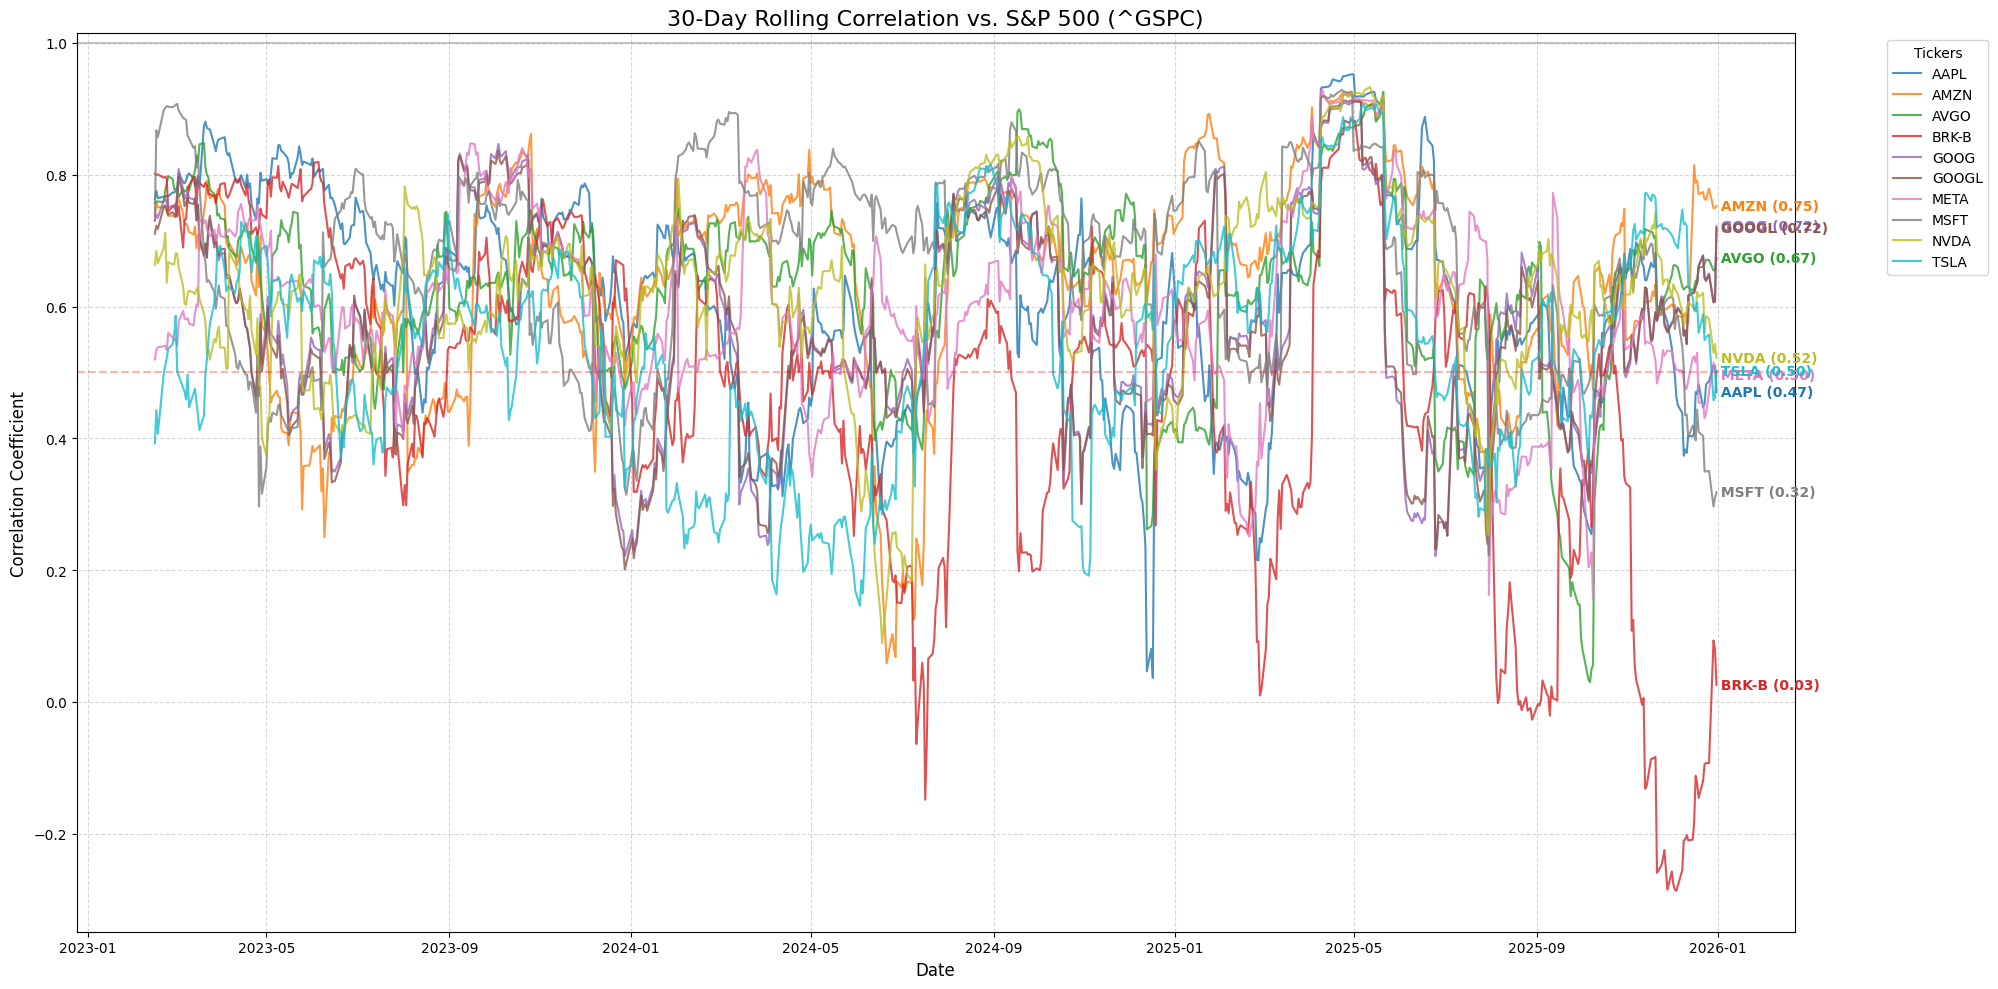

In [74]:
window = 30
rolling_corr = returns.rolling(window=window).corr(returns['^GSPC'])
rolling_corr = rolling_corr.drop(columns=['^GSPC'])

colors = plt.cm.tab10(range(len(rolling_corr.columns)))

for i, column in enumerate(rolling_corr.columns):
    plt.plot(rolling_corr.index, rolling_corr[column], label=column, alpha=0.8)

    last_date = rolling_corr.index[-1]
    last_val = rolling_corr[column].iloc[-1]
    plt.text(last_date, last_val, f' {column} ({last_val:.2f})',
             va='center', color=colors[i], fontweight='bold')

# Formatting the Chart
plt.title(f'{window}-Day Rolling Correlation vs. S&P 500 (^GSPC)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.axhline(y=1, color='black', linestyle='-', alpha=0.2) # Perfect correlation line
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3) # "Low" correlation benchmark
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Tickers")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

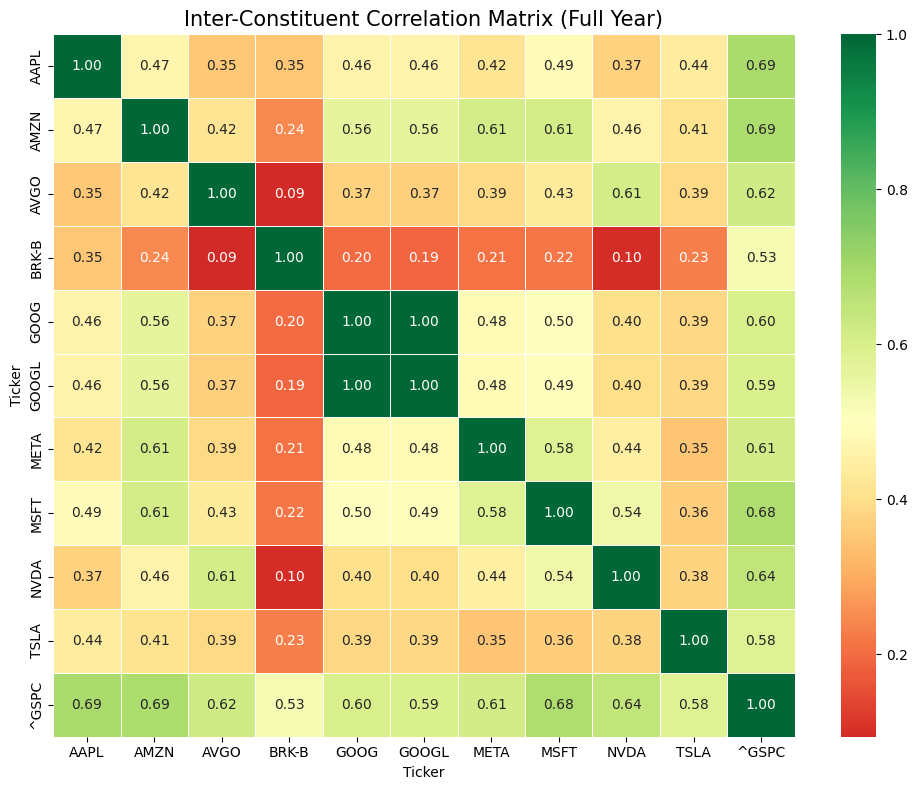

In [77]:
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,       # Show the numeric values
            cmap='RdYlGn',    # Red (Low) to Green (High)
            center=0.5,       # Center the color bar
            fmt=".2f",        # Decimal places
            linewidths=0.5)

plt.title('Inter-Constituent Correlation Matrix (Full Year)', fontsize=15)
plt.tight_layout()
plt.show()

In [81]:
market_var = returns['^GSPC'].var()

betas = {}
for stock in returns.columns:
    if stock == '^GSPC':
        continue

    # Formula: Covariance(Stock, Index) / Variance(Index)
    covariance = returns[stock].cov(returns['^GSPC'])
    beta = covariance / market_var
    betas[stock] = beta

beta_series = pd.Series(betas).sort_values(ascending=False)
print("Current Beta Relative to S&P 500:")
print(beta_series)

Current Beta Relative to S&P 500:
TSLA     2.321269
NVDA     2.147525
AVGO     1.950845
META     1.548251
AMZN     1.458303
GOOG     1.196158
GOOGL    1.192801
AAPL     1.171117
MSFT     1.043680
BRK-B    0.551691
dtype: float64


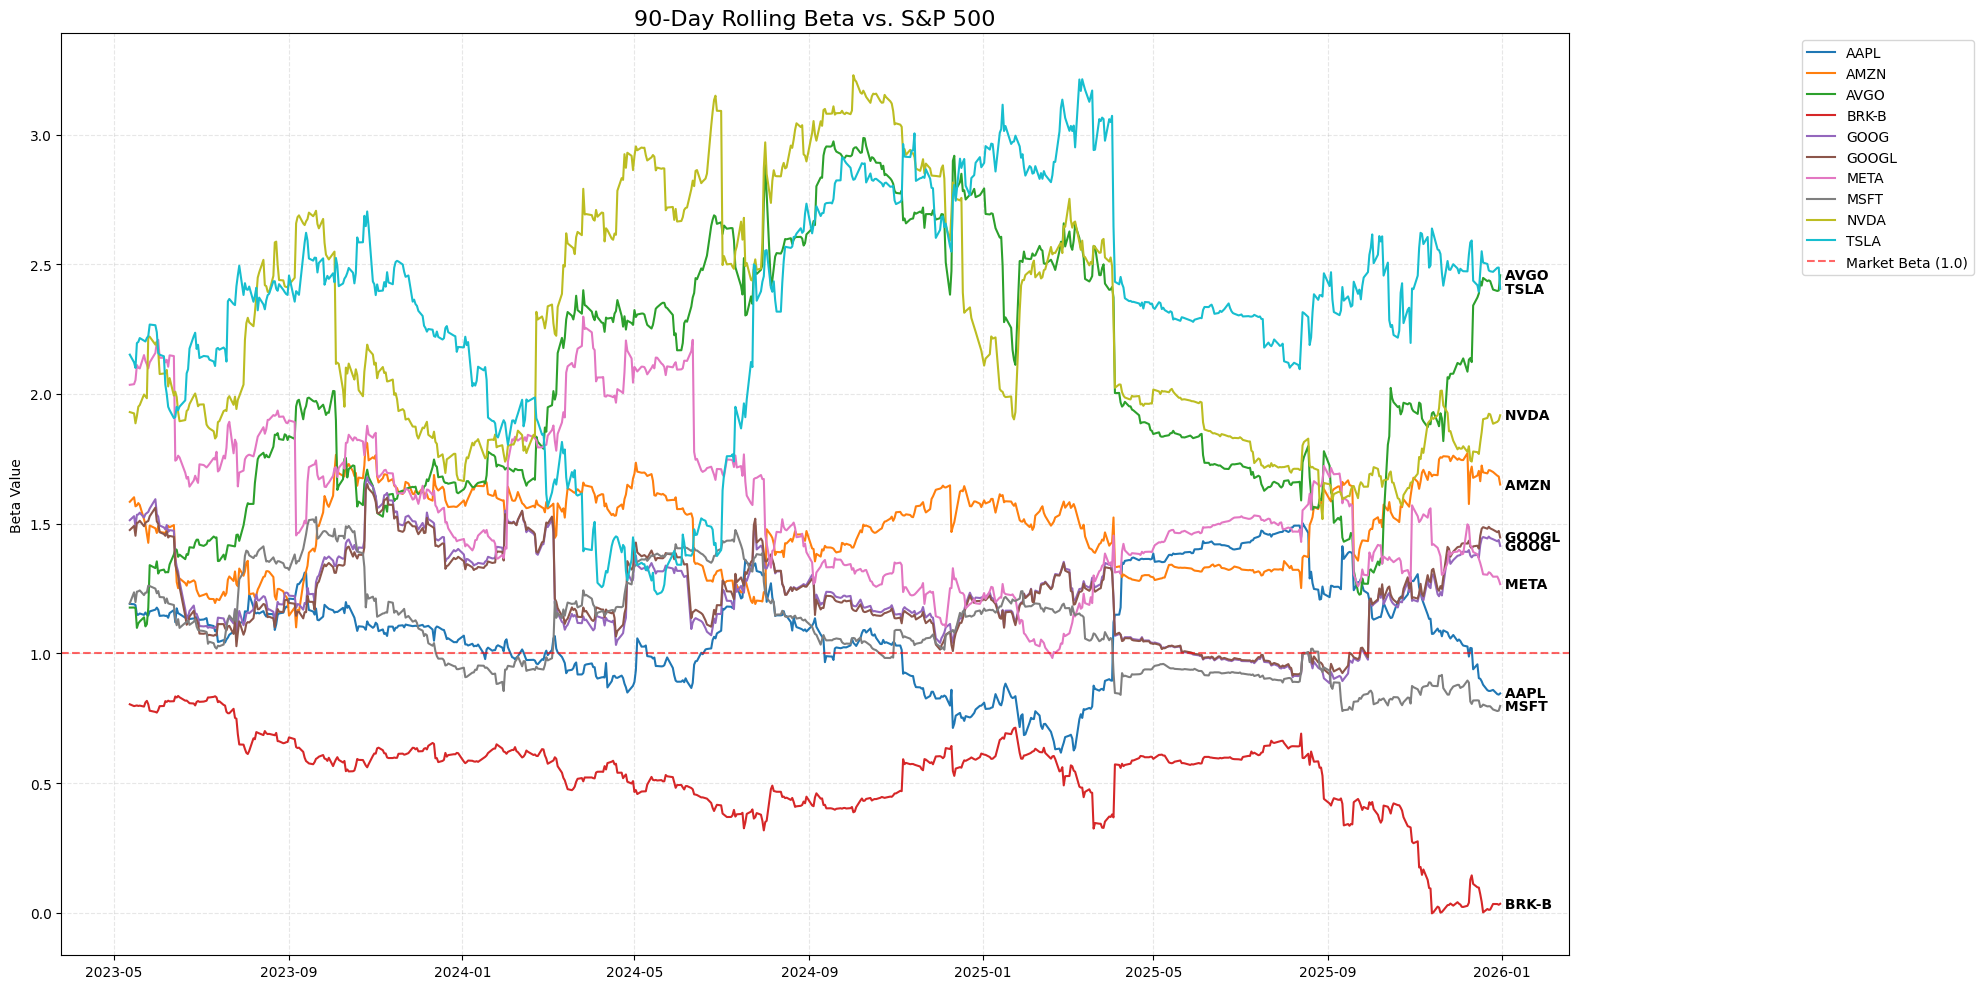

In [84]:
window = 90

rolling_cov = returns.rolling(window=window).cov(returns['^GSPC'])
rolling_market_var = returns['^GSPC'].rolling(window=window).var()

rolling_beta = rolling_cov.divide(rolling_market_var, axis=0).drop(columns=['^GSPC']).dropna()

for column in rolling_beta.columns:
    plt.plot(rolling_beta.index, rolling_beta[column], label=column)

    # Add label at the end of the line
    plt.text(rolling_beta.index[-1], rolling_beta[column].iloc[-1], f' {column}',
             va='center', fontweight='bold')

plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.6, label='Market Beta (1.0)')
plt.title(f'{window}-Day Rolling Beta vs. S&P 500', fontsize=16)
plt.ylabel('Beta Value')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

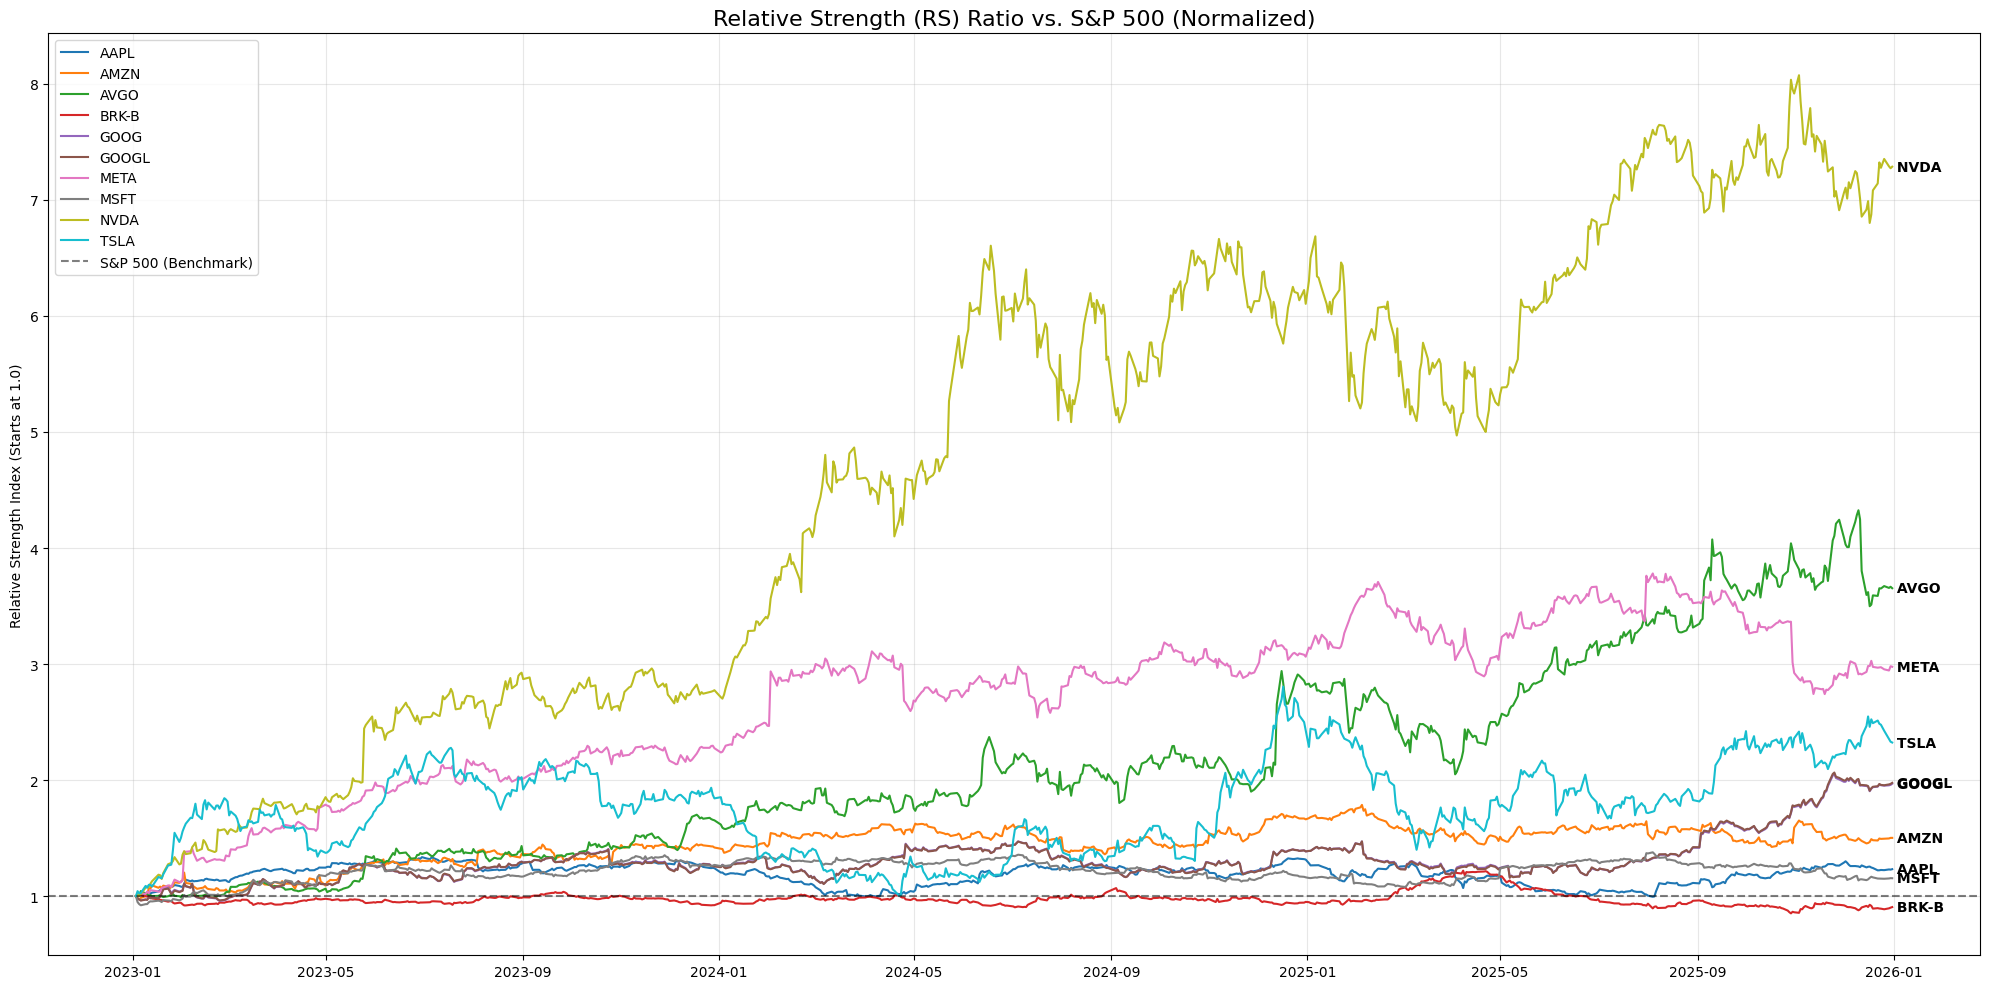

In [99]:
rs_ratios = data.div(data['^GSPC'], axis=0).drop(columns=['^GSPC'])
rs_normalized = rs_ratios / rs_ratios.iloc[0]

for column in rs_normalized.columns:
    plt.plot(rs_normalized.index, rs_normalized[column], label=column)

    # Label the end of the line
    plt.text(rs_normalized.index[-1], rs_normalized[column].iloc[-1], f' {column}',
             fontweight='bold', va='center')

plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='S&P 500 (Benchmark)')

plt.title('Relative Strength (RS) Ratio vs. S&P 500 (Normalized)', fontsize=16)
plt.ylabel('Relative Strength Index (Starts at 1.0)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

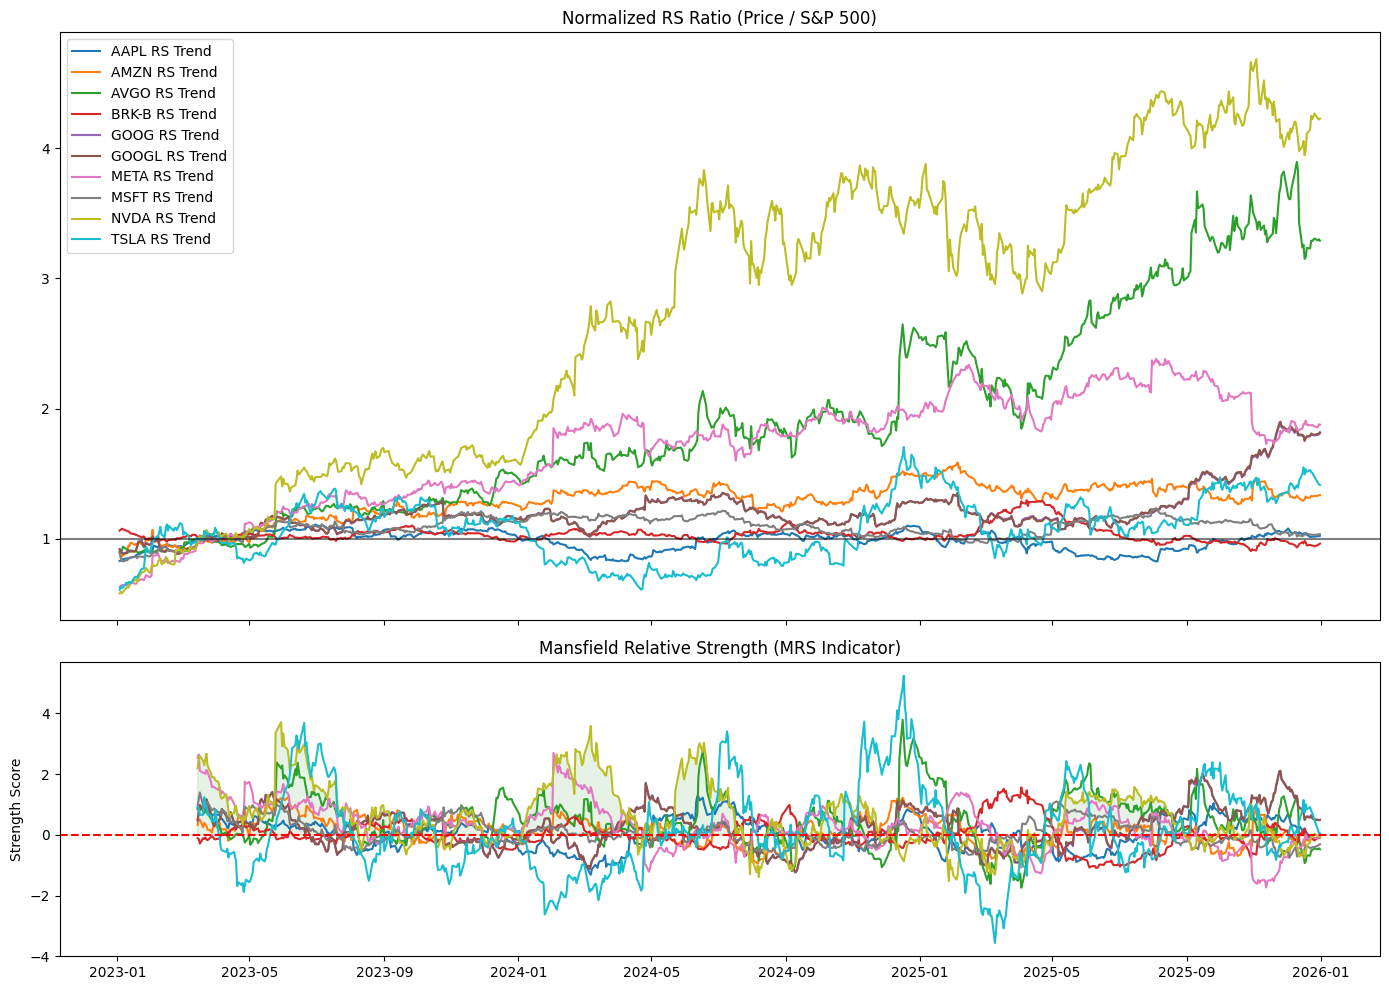

In [100]:
window = 50

mrs = pd.DataFrame(index=rs_ratios.index)

for col in rs_ratios.columns:
    sma_rs = rs_ratios[col].rolling(window=window).mean()
    # We multiply by 10 to make the scale easier to read (standard practice)
    mrs[col] = ((rs_ratios[col] / sma_rs) - 1) * 10

mrs = mrs.dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

rs_norm = rs_ratios / rs_ratios.iloc[window]

for col in rs_norm.columns:
    ax1.plot(rs_norm.index, rs_norm[col], label=f"{col} RS Trend")

ax1.axhline(1.0, color='black', alpha=0.5)
ax1.set_title("Normalized RS Ratio (Price / S&P 500)")
ax1.legend()

for col in mrs.columns:
    ax2.plot(mrs.index, mrs[col], label=f"{col} MRS")

ax2.axhline(0, color='red', linestyle='--', linewidth=1.5) # The Breakout Line
ax2.set_title("Mansfield Relative Strength (MRS Indicator)")
ax2.set_ylabel("Strength Score")
ax2.fill_between(mrs.index, mrs['NVDA'], 0, where=(mrs['NVDA'] >= 0), color='green', alpha=0.1) # Example highlight

plt.tight_layout()
plt.show()

In [95]:
tnx = yf.Ticker("^TNX")
current_yield = tnx.history(period="1d")['Close'].iloc[-1]
risk_free_rate = current_yield / 100

daily_rf = (1 + risk_free_rate)**(1/252) - 1
print(f"Current 10Y Treasury Yield: {current_yield:.2f}%")
print(f"Calculated Daily Risk-Free Rate: {daily_rf:.6f}")

annualized_returns = returns.mean() * 252
market_return = annualized_returns['^GSPC']

alphas = {}
for stock in returns.columns:
    if stock == '^GSPC': continue

    beta = beta_series[stock]
    actual_return = annualized_returns[stock]

    # CAPM Expected Return = Rf + Beta * (Rm - Rf)
    expected_return = risk_free_rate + beta * (market_return - risk_free_rate)
    alphas[stock] = actual_return - expected_return

alpha_df = pd.DataFrame.from_dict(alphas, orient='index', columns=['Alpha'])
print("\nFinal Alpha Rankings:")
print(alpha_df.sort_values(by='Alpha', ascending=False).map('{:.2%}'.format))

Current 10Y Treasury Yield: 4.14%
Calculated Daily Risk-Free Rate: 0.000161

Final Alpha Rankings:
        Alpha
NVDA   59.06%
AVGO   37.74%
META   33.50%
TSLA   23.15%
GOOGL  23.14%
GOOG   22.90%
AMZN   10.04%
AAPL    6.31%
MSFT    5.65%
BRK-B   4.22%


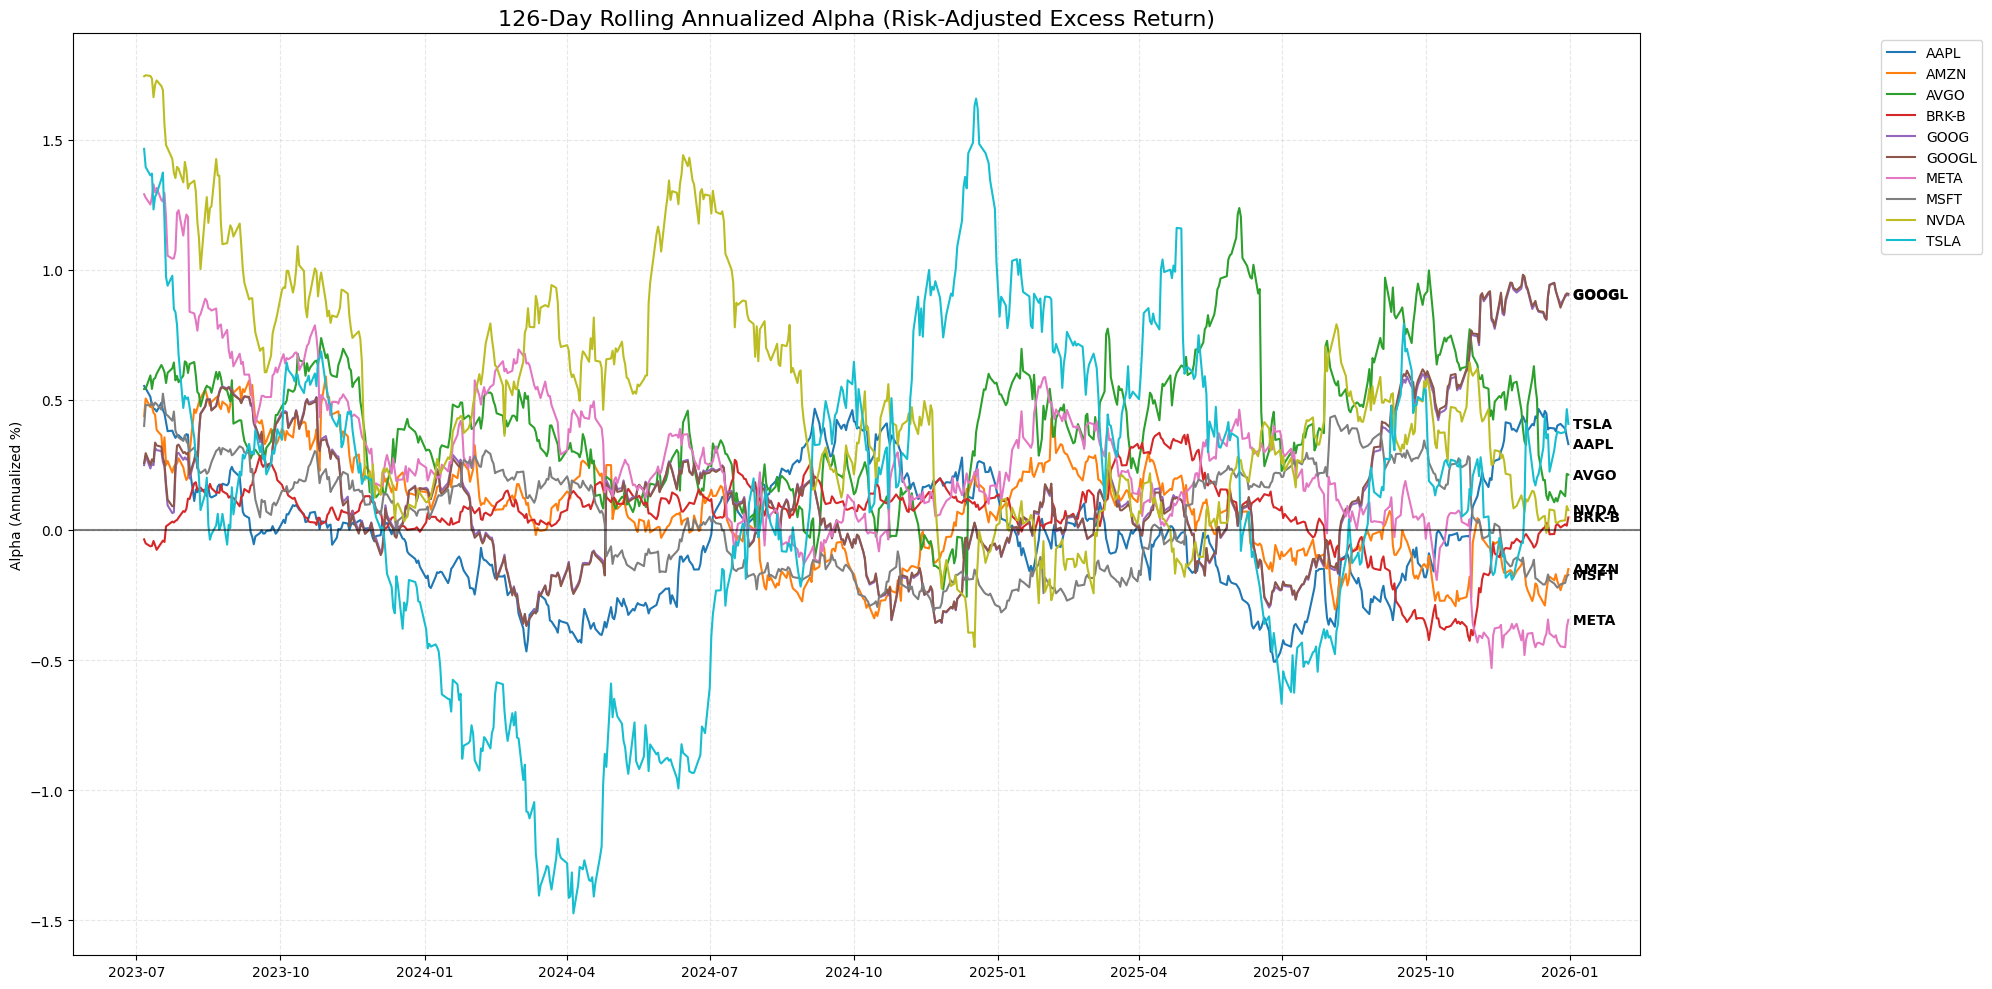

In [98]:
window = 126

tnx = yf.Ticker("^TNX").history(period="1d")['Close'].iloc[-1] / 100
daily_rf = (1 + tnx)**(1/252) - 1

rolling_cov = returns.rolling(window=window).cov(returns['^GSPC'])
rolling_market_var = returns['^GSPC'].rolling(window=window).var()
rolling_beta = rolling_cov.divide(rolling_market_var, axis=0).drop(columns=['^GSPC'])

rolling_stock_ret = returns.rolling(window=window).mean() * 252
rolling_market_ret = rolling_stock_ret['^GSPC']

rolling_alpha = pd.DataFrame(index=returns.index)

for stock in rolling_beta.columns:
    expected_ret = tnx + rolling_beta[stock] * (rolling_market_ret - tnx)
    rolling_alpha[stock] = rolling_stock_ret[stock] - expected_ret

rolling_alpha = rolling_alpha.dropna()

for column in rolling_alpha.columns:
    plt.plot(rolling_alpha.index, rolling_alpha[column], label=column)

    # Label at the end of the line
    plt.text(rolling_alpha.index[-1], rolling_alpha[column].iloc[-1], f' {column}',
             va='center', fontweight='bold', fontsize=10)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
plt.title(f'{window}-Day Rolling Annualized Alpha (Risk-Adjusted Excess Return)', fontsize=16)
plt.ylabel('Alpha (Annualized %)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

In [104]:
index_ticker = "^GSPC"
weights = {}

print("Fetching Market Caps for Weighting...")
for t in tickers:
    info = yf.Ticker(t).info
    weights[t] = info.get('marketCap', 0)

total_mcap = sum(weights.values())
for t in weights:
    weights[t] = weights[t] / total_mcap

contribution = returns[tickers].multiply(pd.Series(weights), axis=1)

latest_day = contribution.iloc[-1]
market_return = returns[index_ticker].iloc[-1]

print(f"\nS&P 500 Return Today: {market_return:.2%}")
print("-" * 30)
print("Top Contributors (In order of impact):")
print(latest_day.sort_values(ascending=False).map('{:.4%}'.format))

Fetching Market Caps for Weighting...

S&P 500 Return Today: -0.74%
------------------------------
Top Contributors (In order of impact):
Ticker
^GSPC    -0.0000%
BRK-B    -0.0080%
GOOG     -0.0329%
GOOGL    -0.0374%
META     -0.0510%
TSLA     -0.0527%
AAPL     -0.0612%
AVGO     -0.0619%
AMZN     -0.0673%
NVDA     -0.0905%
MSFT     -0.1009%
Name: 2025-12-31 00:00:00, dtype: object


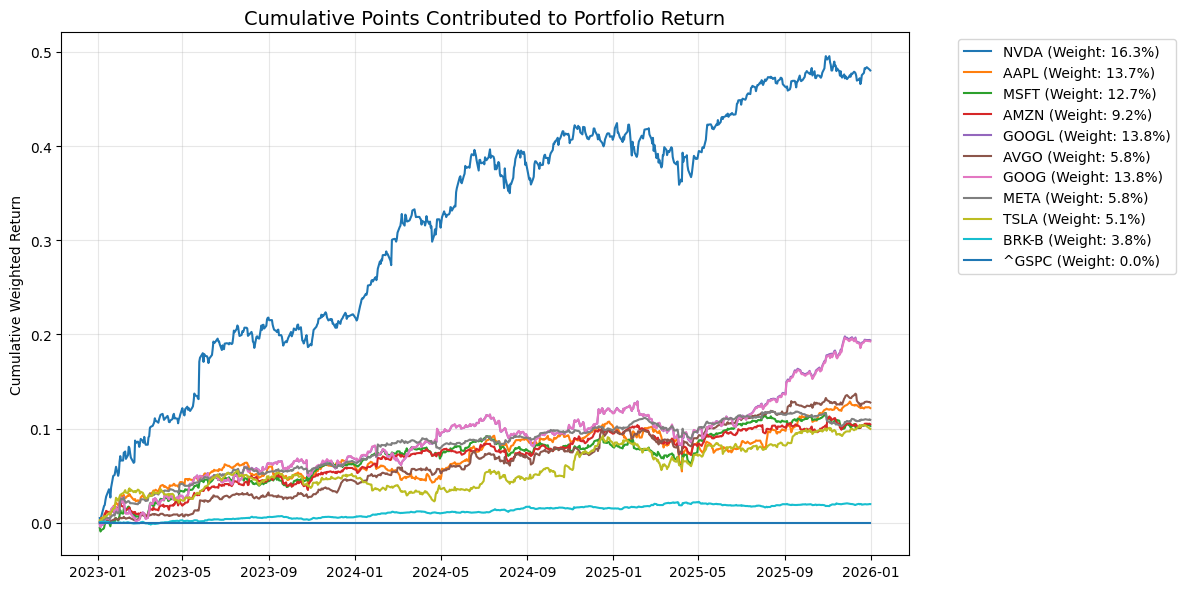

In [105]:
cum_contrib = contribution.cumsum()

plt.figure(figsize=(12, 6))
for col in cum_contrib.columns:
    plt.plot(cum_contrib.index, cum_contrib[col], label=f"{col} (Weight: {weights[col]:.1%})")

plt.title("Cumulative Points Contributed to Portfolio Return", fontsize=14)
plt.ylabel("Cumulative Weighted Return")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
volatility = returns.std() * np.sqrt(252)

vol_df = pd.DataFrame(volatility, columns=['Annualized Volatility'])
vol_df['Relative to Index'] = vol_df['Annualized Volatility'] / vol_df.loc['^GSPC', 'Annualized Volatility']
vol_df = vol_df.sort_values(by='Annualized Volatility', ascending=False)

print("Annualized Volatility Comparison:")
print(vol_df.map('{:.2%}'.format if isinstance(vol_df, float) else '{:.2f}'.format))

Annualized Volatility Comparison:
       Annualized Volatility Relative to Index
Ticker                                        
TSLA                    0.60              3.98
NVDA                    0.50              3.33
AVGO                    0.47              3.15
META                    0.38              2.53
AMZN                    0.32              2.12
GOOGL                   0.30              2.01
GOOG                    0.30              2.00
AAPL                    0.26              1.70
MSFT                    0.23              1.54
BRK-B                   0.16              1.05
^GSPC                   0.15              1.00


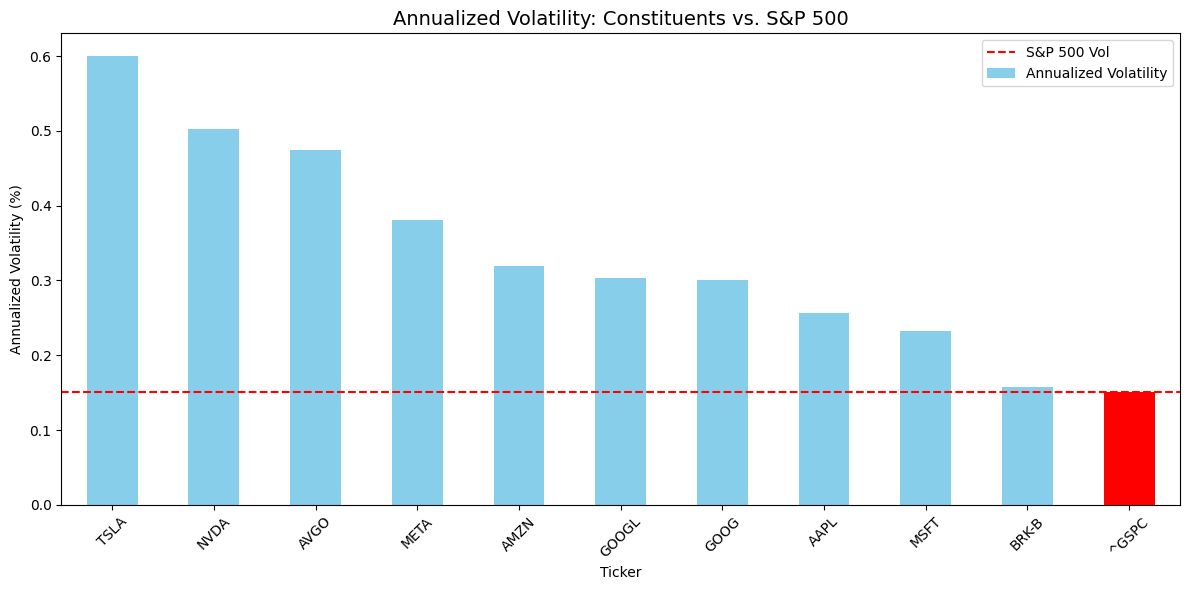

In [115]:
plt.figure(figsize=(12, 6))
colors = ['red' if x == '^GSPC' else 'skyblue' for x in vol_df.index]

vol_df['Annualized Volatility'].plot(kind='bar', color=colors)
plt.axhline(y=vol_df.loc['^GSPC', 'Annualized Volatility'], color='red', linestyle='--', label='S&P 500 Vol')

plt.title('Annualized Volatility: Constituents vs. S&P 500', fontsize=14)
plt.ylabel('Annualized Volatility (%)')
plt.xlabel('Ticker')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

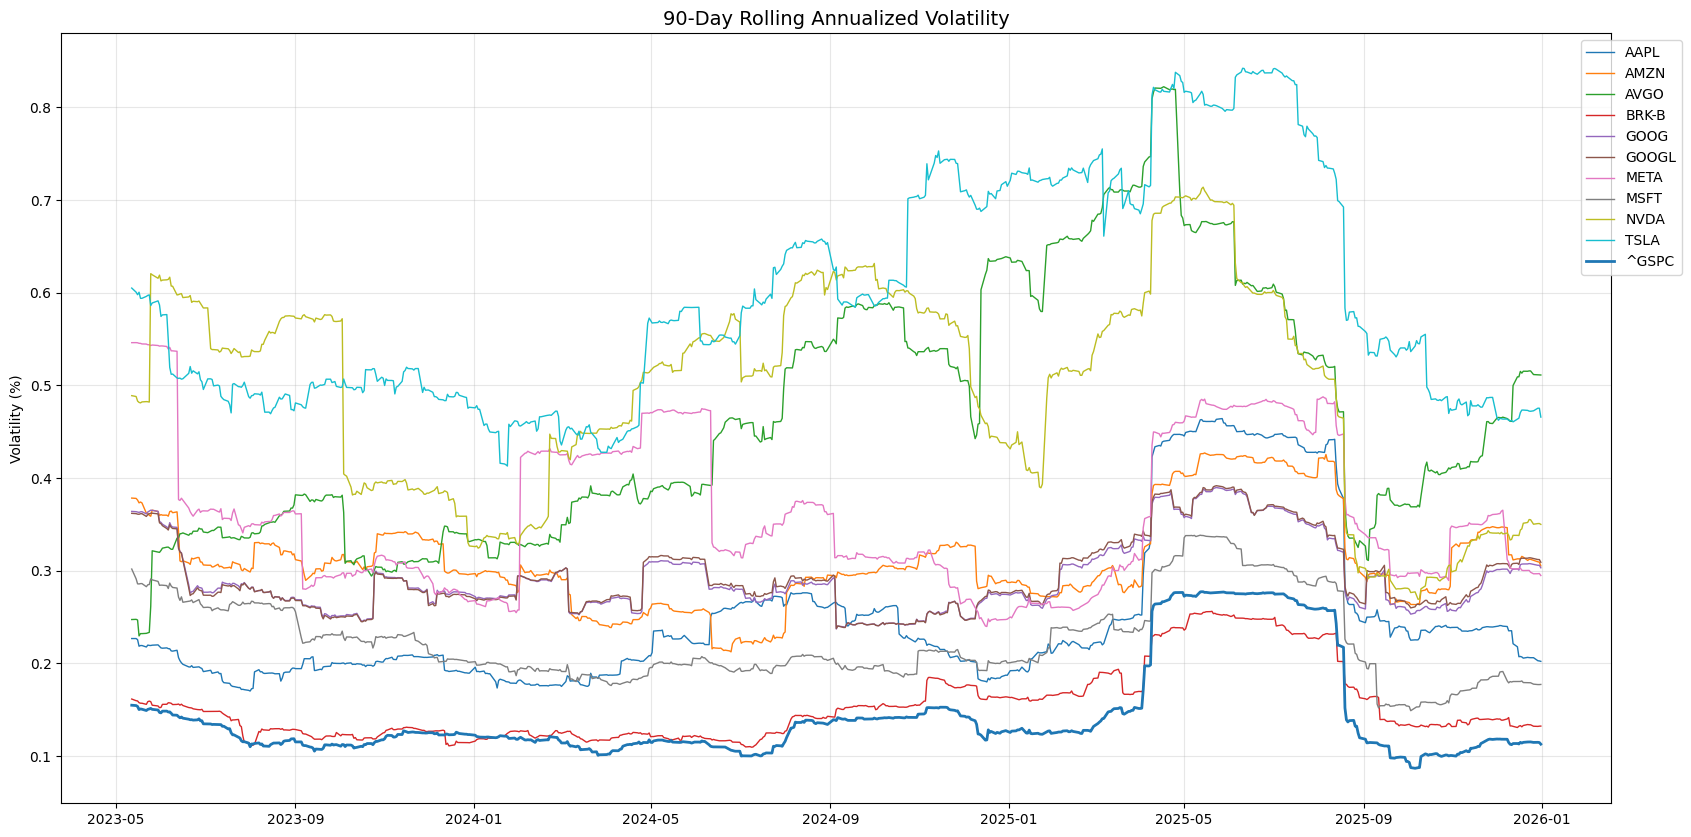

In [117]:
# 90-day rolling annualized volatility
rolling_vol = returns.rolling(window=90).std() * np.sqrt(252)

for col in rolling_vol.columns:
    width = 2 if col == '^GSPC' else 1
    plt.plot(rolling_vol.index, rolling_vol[col], label=col, linewidth=width)

plt.title('90-Day Rolling Annualized Volatility', fontsize=14)
plt.ylabel('Volatility (%)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()